# Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv(r"C:\Users\kisho\Downloads\Voyage_Analytics\Data\flights.csv")

In [3]:
df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [4]:
df.shape

(271888, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


In [6]:
df.describe()

,travelCode,userCode,price,time,distance
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535
std,39243.724665,389.523127,362.31189,0.542541,208.851288
min,0.000000,0.000000,301.51000,0.440000,168.220000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000


In [7]:
print(df.isnull().sum())

travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64


# EDA

#### Price Distribution

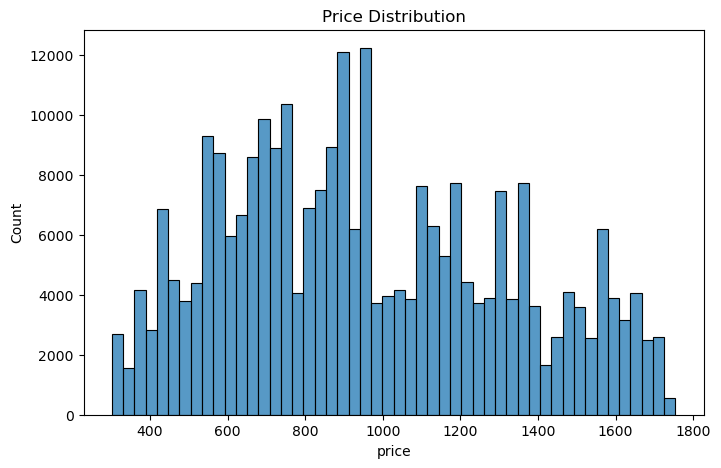

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50)
plt.title("Price Distribution")
plt.show()

#### Price vs Distance

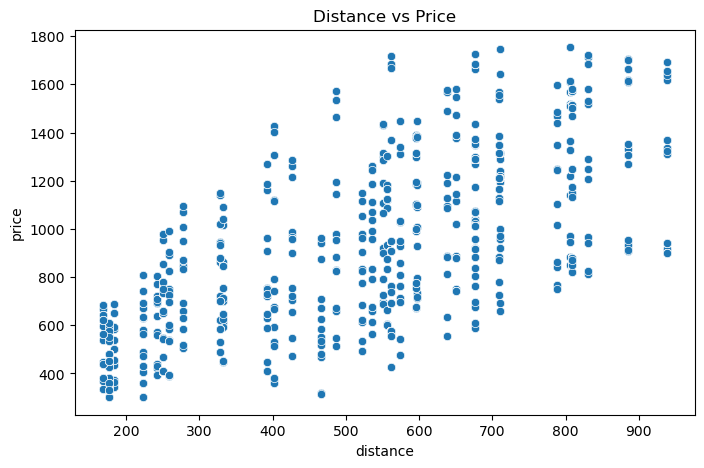

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['distance'], y=df['price'])
plt.title("Distance vs Price")
plt.show()

#### Flight Type vs Price 

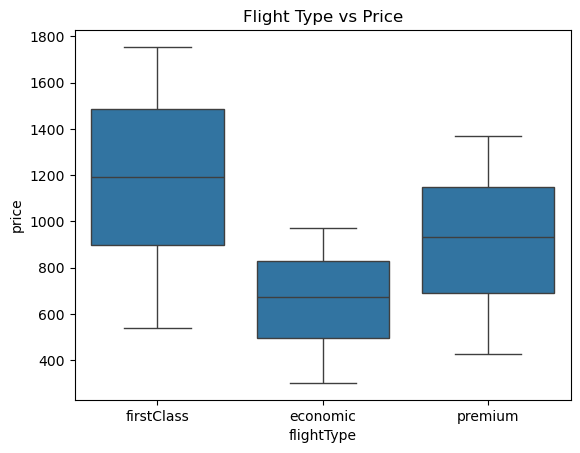

In [10]:
sns.boxplot(x=df['flightType'], y=df['price'])
plt.title("Flight Type vs Price")
plt.show()

#### Agency vs Price

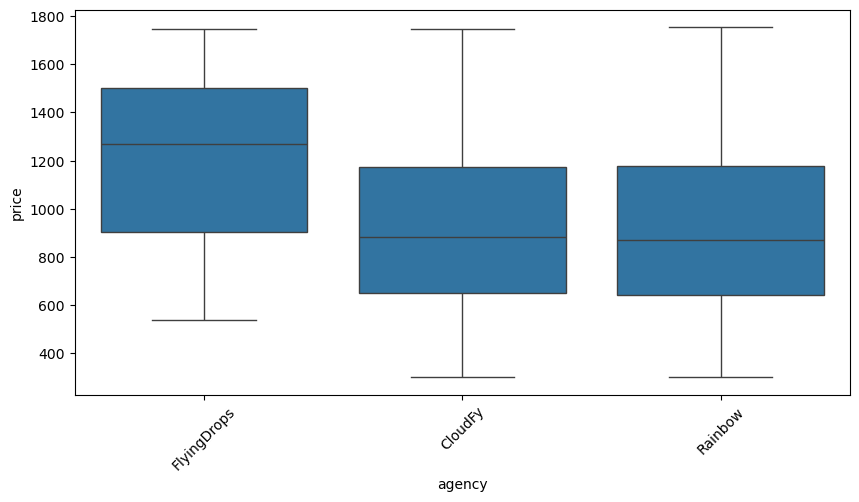

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['agency'], y=df['price'])
plt.xticks(rotation=45)
plt.show()

In [12]:
# Date conversion 
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [13]:
# droping old Date column
df = df.drop('date', axis=1)

In [14]:
df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,year,month,day
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019,9,26
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019,9,30
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019,10,3
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019,10,4
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019,10,10


In [15]:
# Encoding categorical features
df = pd.get_dummies(df, columns=['from','to','flightType','agency'], drop_first=True)

In [16]:
df.head()

,travelCode,userCode,price,time,distance,year,month,day,from_Brasilia (DF),from_Campo Grande (MS),...,to_Florianopolis (SC),to_Natal (RN),to_Recife (PE),to_Rio de Janeiro (RJ),to_Salvador (BH),to_Sao Paulo (SP),flightType_firstClass,flightType_premium,agency_FlyingDrops,agency_Rainbow
0,0,0,1434.38,1.76,676.53,2019,9,26,False,False,...,True,False,False,False,False,False,True,False,True,False
1,0,0,1292.29,1.76,676.53,2019,9,30,False,False,...,False,False,True,False,False,False,True,False,True,False
2,1,0,1487.52,1.66,637.56,2019,10,3,True,False,...,True,False,False,False,False,False,True,False,False,False
3,1,0,1127.36,1.66,637.56,2019,10,4,False,False,...,False,False,False,False,False,False,True,False,False,False
4,2,0,1684.05,2.16,830.86,2019,10,10,False,False,...,False,False,False,False,True,False,True,False,False,False


In [17]:
# Features and target selection
X = df.drop('price', axis=1)
y = df['price']

In [18]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
# Model Training
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [20]:
# Predictions
y_pred = model.predict(X_test)

In [21]:
# Linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 81.32573172430037
MSE: 10640.196111306135
RMSE: 103.15132627022366
R2 Score: 0.9192512680636189


In [22]:
# Random forest model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_rf))

R2 Score: 0.9999989825342107


In [23]:
# XGBoost model
import xgboost as xgb
xg_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xg_reg.fit(X_train, y_train)
y_pred_xgb = xg_reg.predict(X_test)
print("XGBoost Performance")

print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2 Score:", r2_score(y_test, y_pred_xgb))

XGBoost Performance
MAE: 11.939589780557547
MSE: 247.2771326546335
RMSE: 15.725047938071079
R2 Score: 0.9981234072483393


In [24]:
# Comparing models
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.919251
1,Random Forest,0.999999
2,XGBoost,0.998123


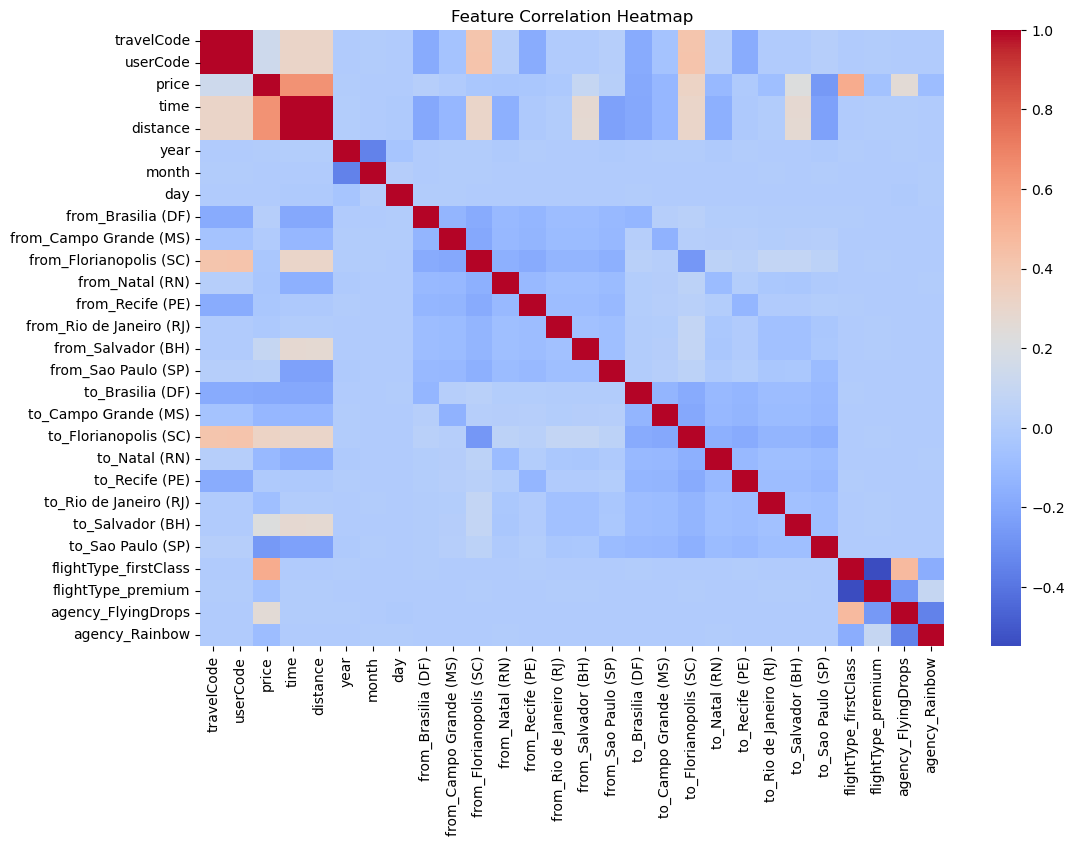

In [25]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

In [26]:
# Feature importance
importances = xg_reg.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
23,flightType_firstClass,0.220519
9,from_Florianopolis (SC),0.146740
2,time,0.125703
17,to_Florianopolis (SC),0.072509
14,from_Sao Paulo (SP),0.071317
3,distance,0.060445
24,flightType_premium,0.059890
22,to_Sao Paulo (SP),0.055613
15,to_Brasilia (DF),0.040815
7,from_Brasilia (DF),0.034149


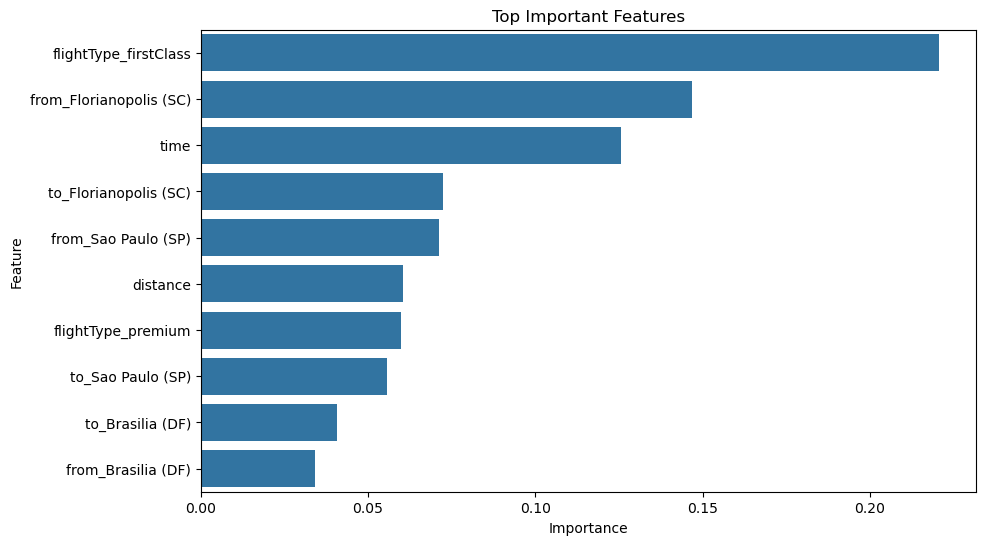

In [27]:
# Feature importance visuals
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top Important Features")

plt.show()

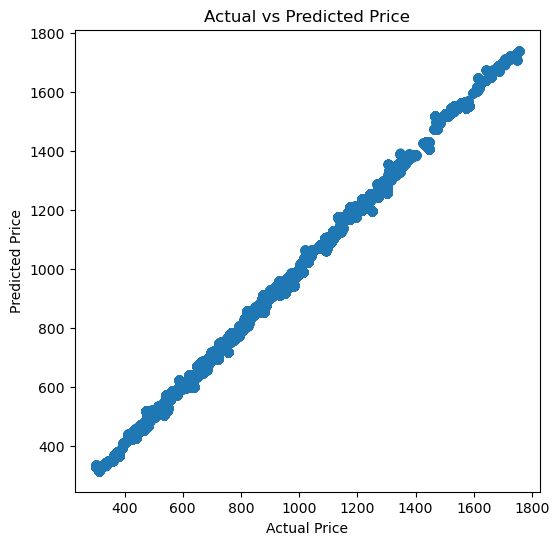

In [28]:
# Actual vs Predicted plot
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_xgb)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

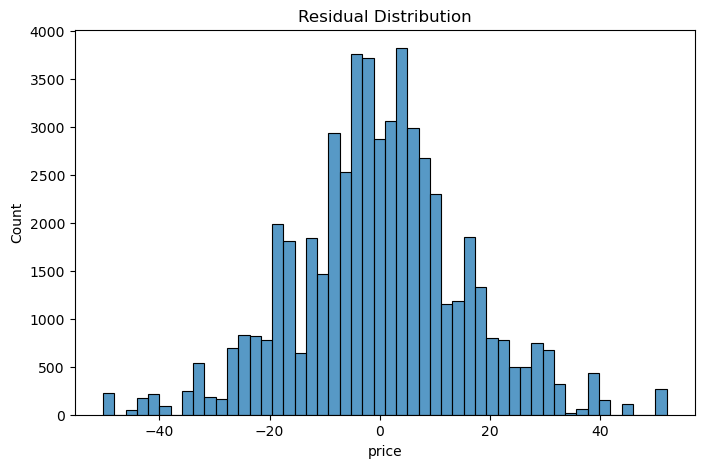

In [29]:
# residual analysis
residuals = y_test - y_pred_xgb

plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=50)

plt.title("Residual Distribution")

plt.show()

In [30]:
# Cross Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xg_reg,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:", cv_scores)
print("Average R2 Score:", cv_scores.mean())

Cross Validation Scores: [0.99775653 0.99806694 0.997932   0.99833123 0.99828597]
Average R2 Score: 0.998074536274759


In [31]:
# Hyper Parameter Tuning
from sklearn.model_selection import GridSearchCV

In [32]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1]
}

In [33]:
grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror'),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [4, 6, 8],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1]},
             scoring='r2', verbose=1)

In [34]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}


In [35]:
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [36]:
y_pred_final = best_model.predict(X_test)

print("Final Model Performance")

print("MAE:", mean_absolute_error(y_test, y_pred_final))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_final)))
print("R2 Score:", r2_score(y_test, y_pred_final))

Final Model Performance
MAE: 0.2205445347465764
RMSE: 0.3455384571886614
R2 Score: 0.9999990938943092


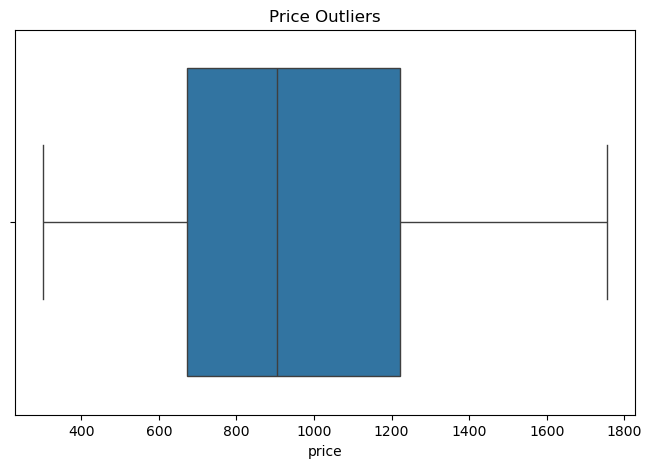

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['price'])

plt.title("Price Outliers")

plt.show()

In [38]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

df = df[
    (df['price'] >= Q1 - 1.5*IQR) &
    (df['price'] <= Q3 + 1.5*IQR)
]

In [41]:
import pickle

with open(r"C:\Users\kisho\Downloads\Voyage_Analytics\Models\flight_price_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [43]:
with open(r"C:\Users\kisho\Downloads\Voyage_Analytics\Models\flight_price_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)